# Projekt – Bernstein–Vazirani algoritmus részleges orákulummal

## Célok

Ebben a projektben a **Bernstein–Vazirani** algoritmust implementáljuk Qiskitben, majd megvizsgáljuk, hogyan viselkedik akkor, ha az orákulum **nem tökéletesen működik**: véletlenszerűen kihagy vagy megfordít bizonyos CNOT kapukat.

## Bernstein–Vazirani röviden

Adott egy $f:\{0,1\}^n \to \{0,1\}$ függvény, amelyről tudjuk, hogy létezik egy rejtett $s \in \{0,1\}^n$ string úgy, hogy

$$f(x) = s \cdot x \pmod{2}.$$

## 1. Importok és beállítások

In [17]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.visualization import plot_histogram

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

REPORT_FIGURES = []

def register_fig(fig, title=None):
    if title is not None:
        fig.suptitle(title, fontsize=11)
    REPORT_FIGURES.append(fig)
    return fig


def draw_circuit(qc):
    try:
        display(qc.draw('mpl'))
    except Exception as e:
        print(qc.draw('text'))

## 2. Standard Bernstein–Vazirani áramkör

In [18]:
def bv_circuit(secret: str) -> QuantumCircuit:
    """Standard Bernstein–Vazirani áramkör a `secret` stringhez."""
    n = len(secret)
    qc = QuantumCircuit(n + 1, n)

    qc.x(n)
    qc.h(n)
    for i in range(n):
        qc.h(i)
    qc.barrier()

    for i, bit in enumerate(reversed(secret)):
        if bit == '1':
            qc.cx(i, n)
    qc.barrier()

    for i in range(n):
        qc.h(i)
    for i in range(n):
        qc.measure(i, i)

    return qc


secret_demo = "1011"
qc_demo = bv_circuit(secret_demo)
draw_circuit(qc_demo)

     ┌───┐      ░                 ░ ┌───┐┌─┐         
q_0: ┤ H ├──────░───■─────────────░─┤ H ├┤M├─────────
     ├───┤      ░   │             ░ ├───┤└╥┘┌─┐      
q_1: ┤ H ├──────░───┼────■────────░─┤ H ├─╫─┤M├──────
     ├───┤      ░   │    │        ░ ├───┤ ║ └╥┘┌─┐   
q_2: ┤ H ├──────░───┼────┼────────░─┤ H ├─╫──╫─┤M├───
     ├───┤      ░   │    │        ░ ├───┤ ║  ║ └╥┘┌─┐
q_3: ┤ H ├──────░───┼────┼────■───░─┤ H ├─╫──╫──╫─┤M├
     ├───┤┌───┐ ░ ┌─┴─┐┌─┴─┐┌─┴─┐ ░ └───┘ ║  ║  ║ └╥┘
q_4: ┤ X ├┤ H ├─░─┤ X ├┤ X ├┤ X ├─░───────╫──╫──╫──╫─
     └───┘└───┘ ░ └───┘└───┘└───┘ ░       ║  ║  ║  ║ 
c: 4/═════════════════════════════════════╩══╩══╩══╩═
                                          0  1  2  3 


In [19]:
def run_circuit(qc: QuantumCircuit, shots: int = 1024, noise_model: NoiseModel = None) -> dict:
    sim = AerSimulator(noise_model=noise_model) if noise_model is not None else AerSimulator()
    tqc = transpile(qc, sim)
    result = sim.run(tqc, shots=shots).result()
    return result.get_counts()


counts_demo = run_circuit(qc_demo, shots=2048)
fig = plot_histogram(counts_demo, title=f"Standard BV \u2013 s = {secret_demo}")
register_fig(fig)
plt.show()

Az orákulum hibátlan: a leggyakoribb (számolt) kimenet **pontosan** a titkos string.

## 3. Részleges orákulum – CNOT kihagyás és megfordítás

Három mód:

- **`skip`**: minden olyan CNOT-ot, amit a standard orákulum alkalmazna, $p$ valószínűséggel kihagy.
- **`flip`**: minden ilyen CNOT-ot $p$ valószínűséggel megfordít (cseréljük a control és target szerepét).
- **`mixed`**: a hibák $p$ valószínűséggel történnek, fele-fele eloszlásban skip vagy flip.

In [20]:
def bv_partial_oracle(secret: str, mode: str = 'skip', p: float = 0.2,
                      rng: random.Random = None) -> QuantumCircuit:
    if rng is None:
        rng = random
    if mode not in ('skip', 'flip', 'mixed'):
        raise ValueError("mode must be 'skip', 'flip', or 'mixed'")

    n = len(secret)
    qc = QuantumCircuit(n + 1, n)
    qc.x(n); qc.h(n)
    for i in range(n):
        qc.h(i)
    qc.barrier()

    for i, bit in enumerate(reversed(secret)):
        if bit != '1':
            continue
        r = rng.random()
        if mode == 'skip':
            if r < p:
                continue  # kihagyott CNOT
            qc.cx(i, n)
        elif mode == 'flip':
            if r < p:
                qc.cx(n, i)  # invertált CNOT
            else:
                qc.cx(i, n)
        else:  # mixed
            if r < p / 2:
                continue
            elif r < p:
                qc.cx(n, i)
            else:
                qc.cx(i, n)
    qc.barrier()

    for i in range(n):
        qc.h(i)
    for i in range(n):
        qc.measure(i, i)
    return qc


rng_demo = random.Random(1)
qc_part = bv_partial_oracle(secret_demo, mode='mixed', p=0.4, rng=rng_demo)
draw_circuit(qc_part)

     ┌───┐      ░            ░ ┌───┐┌─┐         
q_0: ┤ H ├──────░────────────░─┤ H ├┤M├─────────
     ├───┤      ░            ░ ├───┤└╥┘┌─┐      
q_1: ┤ H ├──────░───■────────░─┤ H ├─╫─┤M├──────
     ├───┤      ░   │        ░ ├───┤ ║ └╥┘┌─┐   
q_2: ┤ H ├──────░───┼────────░─┤ H ├─╫──╫─┤M├───
     ├───┤      ░   │        ░ ├───┤ ║  ║ └╥┘┌─┐
q_3: ┤ H ├──────░───┼────■───░─┤ H ├─╫──╫──╫─┤M├
     ├───┤┌───┐ ░ ┌─┴─┐┌─┴─┐ ░ └───┘ ║  ║  ║ └╥┘
q_4: ┤ X ├┤ H ├─░─┤ X ├┤ X ├─░───────╫──╫──╫──╫─
     └───┘└───┘ ░ └───┘└───┘ ░       ║  ║  ║  ║ 
c: 4/════════════════════════════════╩══╩══╩══╩═
                                     0  1  2  3 


### 3.1 Hisztogramok összehasonlítása

In [21]:
def compare_modes(secret: str, p: float = 0.3, shots: int = 4096) -> dict:
    rng = random.Random(7)
    results = {}
    results['standard'] = run_circuit(bv_circuit(secret), shots=shots)
    for mode in ('skip', 'flip', 'mixed'):
        qc = bv_partial_oracle(secret, mode=mode, p=p, rng=rng)
        results[mode] = run_circuit(qc, shots=shots)
    return results


results_modes = compare_modes(secret_demo, p=0.3, shots=4096)
fig = plot_histogram(
    list(results_modes.values()),
    legend=list(results_modes.keys()),
    title=f"BV m\u00f3dok \u00f6sszehasonl\u00edt\u00e1sa \u2013 s = {secret_demo}, p = 0.3",
    figsize=(10, 5),
)
register_fig(fig)
plt.show()

## 4. Több secret string és különböző $n$

In [22]:
def success_rate(counts: dict, secret: str) -> float:
    total = sum(counts.values())
    return counts.get(secret, 0) / total if total else 0.0


SECRETS = ['1', '10', '101', '1011', '11010', '101101', '1110101']
rows = []
for s in SECRETS:
    c = run_circuit(bv_circuit(s), shots=2048)
    rows.append((len(s), s, success_rate(c, s)))

print(f"{'n':>3}  {'secret':>8}  {'siker\u00e1r\u00e1ny':>10}")
for n, s, sr in rows:
    print(f"{n:>3}  {s:>8}  {sr:>10.3f}")

  n    secret  sikerárány
  1         1       1.000
  2        10       1.000
  3       101       1.000
  4      1011       1.000
  5     11010       1.000
  6    101101       1.000
  7   1110101       1.000


Zaj nélkül minden esetben ~100% a sikerárány – pontosan ezt várjuk a BV determinisztikussága miatt.

## 5. Iterációk vs. sikerárány görbe (részleges orákulum)

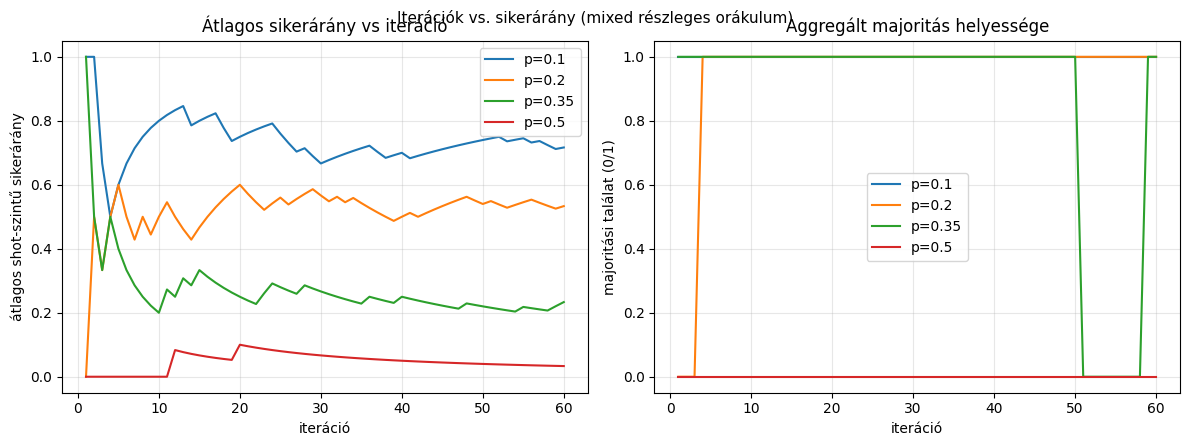

In [23]:
def iterate_partial(secret: str, mode: str, p: float, n_iter: int = 50,
                    shots: int = 512, seed: int = 0):
    rng = random.Random(seed)
    agg = {}
    majority_hits = []
    avg_success = []
    per_iter_success = []
    for k in range(1, n_iter + 1):
        qc = bv_partial_oracle(secret, mode=mode, p=p, rng=rng)
        counts = run_circuit(qc, shots=shots)
        per_iter_success.append(success_rate(counts, secret))
        for outcome, c in counts.items():
            agg[outcome] = agg.get(outcome, 0) + c
        # majoritási nézet az aggregált counts alapján
        top = max(agg.items(), key=lambda kv: kv[1])[0]
        majority_hits.append(int(top == secret))
        avg_success.append(sum(per_iter_success) / k)
    return {
        'agg_counts': agg,
        'majority_hit': np.array(majority_hits),
        'avg_success': np.array(avg_success),
        'per_iter_success': np.array(per_iter_success),
    }


secret_iter = '1011'
P_VALUES = [0.1, 0.2, 0.35, 0.5]
iter_results = {p: iterate_partial(secret_iter, mode='mixed', p=p, n_iter=60,
                                   shots=512, seed=100 + int(p * 100))
                for p in P_VALUES}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for p, res in iter_results.items():
    axes[0].plot(range(1, len(res['avg_success']) + 1), res['avg_success'],
                 label=f'p={p}')
    axes[1].plot(range(1, len(res['majority_hit']) + 1), res['majority_hit'],
                 label=f'p={p}')
axes[0].set_xlabel('iter\u00e1ci\u00f3')
axes[0].set_ylabel('\u00e1tlagos shot-szint\u0171 siker\u00e1r\u00e1ny')
axes[0].set_title('\u00c1tlagos siker\u00e1r\u00e1ny vs iter\u00e1ci\u00f3')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].set_xlabel('iter\u00e1ci\u00f3')
axes[1].set_ylabel('majorit\u00e1si tal\u00e1lat (0/1)')
axes[1].set_title('Aggreg\u00e1lt majorit\u00e1s helyess\u00e9ge')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
fig.tight_layout()
register_fig(fig, 'Iter\u00e1ci\u00f3k vs. siker\u00e1r\u00e1ny (mixed r\u00e9szleges or\u00e1kulum)')
plt.show()

## 6. Shots számának hatása a konvergenciára

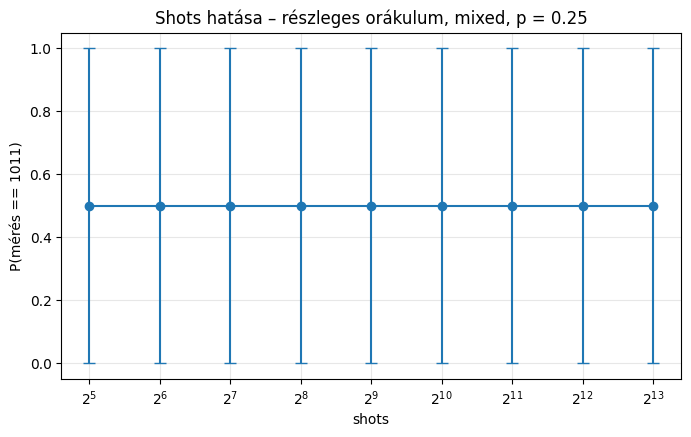

In [24]:
SHOTS_LIST = [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
secret_shots = '1011'
p_fix = 0.25
shots_curve = []
for sh in SHOTS_LIST:
    rng = random.Random(321)
    runs = []
    for _ in range(20):  # átlagolás
        qc = bv_partial_oracle(secret_shots, mode='mixed', p=p_fix, rng=rng)
        c = run_circuit(qc, shots=sh)
        runs.append(success_rate(c, secret_shots))
    shots_curve.append((sh, np.mean(runs), np.std(runs)))

xs = [x[0] for x in shots_curve]
means = [x[1] for x in shots_curve]
stds = [x[2] for x in shots_curve]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(xs, means, yerr=stds, marker='o', capsize=4)
ax.set_xscale('log', base=2)
ax.set_xlabel('shots')
ax.set_ylabel(f'P(m\u00e9r\u00e9s == {secret_shots})')
ax.set_title(f'Shots hat\u00e1sa \u2013 r\u00e9szleges or\u00e1kulum, mixed, p = {p_fix}')
ax.grid(True, alpha=0.3)
register_fig(fig)
plt.show()

## 7. Zajmodell (valós hardver szimulációja)

In [25]:
def make_noise_model(p1: float = 0.001, p2: float = 0.01) -> NoiseModel:
    nm = NoiseModel()
    err1 = depolarizing_error(p1, 1)
    err2 = depolarizing_error(p2, 2)
    nm.add_all_qubit_quantum_error(err1, ['h', 'x', 'rz', 'sx', 'u', 'u1', 'u2', 'u3'])
    nm.add_all_qubit_quantum_error(err2, ['cx'])
    return nm


noise = make_noise_model(p1=0.002, p2=0.02)
print(noise)

NoiseModel:
  Basis gates: ['cx', 'h', 'id', 'rz', 'sx', 'u', 'u1', 'u2', 'u3', 'x']
  Instructions with noise: ['u1', 'u3', 'sx', 'cx', 'u2', 'h', 'rz', 'x', 'u']
  All-qubits errors: ['h', 'x', 'rz', 'sx', 'u', 'u1', 'u2', 'u3', 'cx']


In [26]:
# Zaj összehasonlítása: hibátlan vs. zajos (különböző p2 szintek)
noise_levels = [
    ('ideal',        None),
    ('gyenge zaj',   make_noise_model(0.001, 0.005)),
    ('k\u00f6zepes zaj', make_noise_model(0.002, 0.02)),
    ('er\u0151s zaj',  make_noise_model(0.01, 0.08)),
]

secret_noise = '10110'
noise_results = []
for name, nm in noise_levels:
    c = run_circuit(bv_circuit(secret_noise), shots=4096, noise_model=nm)
    noise_results.append((name, c, success_rate(c, secret_noise)))

for name, _, sr in noise_results:
    print(f'{name:>16s}  siker\u00e1r\u00e1ny = {sr:.3f}')

fig = plot_histogram(
    [r[1] for r in noise_results],
    legend=[r[0] for r in noise_results],
    title=f'Zajszintek \u00f6sszehasonl\u00edt\u00e1sa \u2013 s = {secret_noise}',
    figsize=(11, 5),
    number_to_keep=8,
)
register_fig(fig)
plt.show()

           ideal  sikerárány = 1.000
      gyenge zaj  sikerárány = 0.982
     közepes zaj  sikerárány = 0.943
        erős zaj  sikerárány = 0.807


### 7.1 Zajos rendszer + részleges orákulum együtt


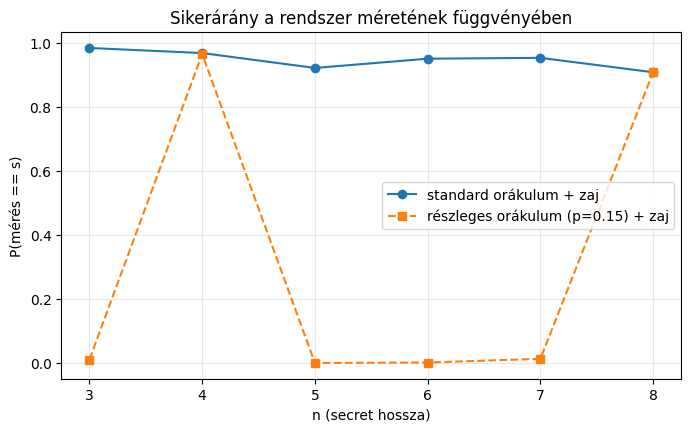

n=3  s=     001  std=0.983  partial=0.011
n=4  s=    1001  std=0.967  partial=0.964
n=5  s=   11111  std=0.921  partial=0.001
n=6  s=  100011  std=0.950  partial=0.002
n=7  s= 1000101  std=0.952  partial=0.014
n=8  s=11110011  std=0.907  partial=0.907


In [27]:
nm_demo = make_noise_model(0.002, 0.02)
N_SWEEP = [3, 4, 5, 6, 7, 8]
p_partial = 0.15
sweep_data = []
rng = random.Random(55)
for n in N_SWEEP:
    secret = ''.join(rng.choice('01') for _ in range(n - 1)) + '1'  # általános
    qc_std   = bv_circuit(secret)
    qc_part_ = bv_partial_oracle(secret, mode='mixed', p=p_partial, rng=rng)
    c_std    = run_circuit(qc_std,   shots=4096, noise_model=nm_demo)
    c_part   = run_circuit(qc_part_, shots=4096, noise_model=nm_demo)
    sweep_data.append({
        'n': n, 'secret': secret,
        'std':     success_rate(c_std,  secret),
        'partial': success_rate(c_part, secret),
    })

xs = [d['n'] for d in sweep_data]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(xs, [d['std']     for d in sweep_data], 'o-', label='standard or\u00e1kulum + zaj')
ax.plot(xs, [d['partial'] for d in sweep_data], 's--', label=f'r\u00e9szleges or\u00e1kulum (p={p_partial}) + zaj')
ax.set_xlabel('n (secret hossza)')
ax.set_ylabel(f'P(m\u00e9r\u00e9s == s)')
ax.set_title('Siker\u00e1r\u00e1ny a rendszer m\u00e9ret\u00e9nek f\u00fcggv\u00e9ny\u00e9ben')
ax.grid(True, alpha=0.3)
ax.legend()
register_fig(fig)
plt.show()

for d in sweep_data:
    print(f"n={d['n']}  s={d['secret']:>8s}  std={d['std']:.3f}  partial={d['partial']:.3f}")

## 8. Valós hardverre jellemző zaj – különböző iterációk


iter  1: argmax =  11010  P(s) = 0.944
iter  2: argmax =  11010  P(s) = 0.940
iter  3: argmax =  11010  P(s) = 0.931
iter  4: argmax =  11010  P(s) = 0.924
iter  5: argmax =  11010  P(s) = 0.940
iter  6: argmax =  11010  P(s) = 0.946
iter  7: argmax =  11010  P(s) = 0.935
iter  8: argmax =  01010  P(s) = 0.017
iter  9: argmax =  01010  P(s) = 0.002
iter 10: argmax =  01010  P(s) = 0.016


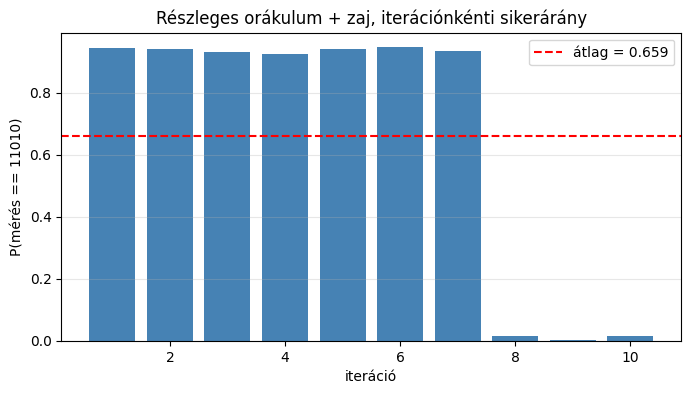

In [28]:
secret_final = '11010'
nm_final = make_noise_model(0.003, 0.025)
iters = 10
all_success = []
rng = random.Random(2024)
for i in range(iters):
    qc = bv_partial_oracle(secret_final, mode='mixed', p=0.2, rng=rng)
    c = run_circuit(qc, shots=2048, noise_model=nm_final)
    sr = success_rate(c, secret_final)
    all_success.append(sr)
    print(f"iter {i+1:2d}: argmax = {max(c, key=c.get):>6s}  P(s) = {sr:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, iters + 1), all_success, color='steelblue')
ax.axhline(np.mean(all_success), color='red', linestyle='--',
           label=f'\u00e1tlag = {np.mean(all_success):.3f}')
ax.set_xlabel('iter\u00e1ci\u00f3')
ax.set_ylabel(f'P(m\u00e9r\u00e9s == {secret_final})')
ax.set_title('R\u00e9szleges or\u00e1kulum + zaj, iter\u00e1ci\u00f3nk\u00e9nti siker\u00e1r\u00e1ny')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
register_fig(fig)
plt.show()

## 9. Összefoglalás

- **Standard BV**: determinisztikus; minden $n$-re 100% sikerárány zaj nélkül.
- **Részleges orákulum, `skip` mód**: a kihagyott CNOT azt jelenti, hogy a kiolvasott string egy bitje *véletlenszerűen* 0 lesz, ami közvetlenül csökkenti annak valószínűségét, hogy $s$-t kapjuk.
- **`flip` mód**: az invertált CNOT nem csupán kihagyja a műveletet, hanem az ancilla és az input qubit között entanglement-et hoz létre más módon, ami **keverék-állapotot** eredményez az input qubiten.
- **Shots**: csak a statisztikai szórást csökkenti, a bias-t nem.
- **Iterációk**: az aggregált majoritási szavazással kis-közepes $p$-nél stabilan visszakapható a helyes $s$.
- **Zaj**: a depolárizáló zaj $n$ növekedésével gyorsan ront, hiszen több CNOT $\Rightarrow$ több hibalehetőség.
- **Bloch-gömb**: jól mutatja, hogy a hiba tiszta állapotból keverék állapotba sodorja a qubitet.

## 10. Konzolos alkalmazás

A `bv_console()` függvény egy interaktív ciklust futtat; `q`/`exit` paranccsal, vagy
lezárt stdin esetén kilép.

In [29]:
def success_rate(counts: dict, secret: str) -> float:
    total = sum(counts.values())
    return counts.get(secret, 0) / total if total else 0.0


def bv_console():
    print('=' * 60)
    print('  Bernstein-Vazirani - konzolos alkalmazas')
    print('=' * 60)
    print("Parancsok: 'q' / 'exit' = kilepes, Enter = alapertelmezett ertek.")

    while True:
        print()
        try:
            s = input('Secret (01 string) [1011]: ').strip() or '1011'
            if s.lower() in ('q', 'exit', 'quit'):
                print('Kilepes.'); break
            if any(c not in '01' for c in s):
                print('Hiba: a secret csak 0/1 karaktereket tartalmazhat.'); continue
            if len(s) > 12:
                print('Hiba: maximum 12 bit ajanlott.'); continue

            mode = input('Mod [standard/skip/flip/mixed] (mixed): ').strip() or 'mixed'
            if mode not in ('standard', 'skip', 'flip', 'mixed'):
                print('Hiba: ismeretlen mod.'); continue

            p_raw     = input('p (hiba valoszinusege, 0..0.9) [0.2]: ').strip()
            p         = float(p_raw) if p_raw else 0.2
            shots_raw = input('shots [2048]: ').strip()
            shots     = int(shots_raw) if shots_raw else 2048
            noise_raw = input('Zajmodell (y/n) [n]: ').strip().lower()
            nm        = make_noise_model(0.002, 0.02) if noise_raw == 'y' else None
        except (EOFError, OSError):
            print('\n(stdin nem elerheto - kilepes.)'); break
        except KeyboardInterrupt:
            print('\nMegszakitva.'); break
        except ValueError as e:
            print(f'Hiba a beolvasasban: {e}'); continue
        except Exception as e:
            # pl. ipykernel StdinNotImplementedError nbconvert --execute alatt
            print(f'(input nem elerheto: {type(e).__name__} - kilepes.)'); break

        # --- futtatas ---
        rng = random.Random()
        if mode == 'standard':
            qc = bv_circuit(s)
        else:
            qc = bv_partial_oracle(s, mode=mode, p=p, rng=rng)
        counts = run_circuit(qc, shots=shots, noise_model=nm)
        sr  = success_rate(counts, s)
        top = max(counts, key=counts.get)

        # --- eredmeny kiirasa ---
        print()
        print(f'--- Eredmeny: s={s}, mode={mode}, p={p}, shots={shots}'
              + (', zajjal' if nm else '') + ' ---')
        print(f'  Leggyakoribb kimenet : {top}')
        print(f'  Valodi secret        : {s}')
        tag = 'helyes' if top == s else 'hibas'
        print(f'  P(mert == s)         : {sr:.3f}   ({tag})')
        print('  Hisztogram (top 8):')
        bar_max = max(counts.values())
        for outcome, c in sorted(counts.items(), key=lambda kv: -kv[1])[:8]:
            bar  = '#' * int(40 * c / bar_max)
            mark = '  <- s' if outcome == s else ''
            print(f'    {outcome:>12s}  {c:>6d}  |{bar}{mark}')


# Elinditjuk az interaktiv ciklust.
# (Nem-interaktiv futtataskor - pl. nbconvert --execute - az input() kivetelt dob,
#  amit a ciklus elegansan lekezel es kilep.)
bv_console()

  Bernstein-Vazirani - konzolos alkalmazas
Parancsok: 'q' / 'exit' = kilepes, Enter = alapertelmezett ertek.


Megszakitva.
